In [1]:
from folde.types import FolDEModelConfig, ModelDiff
from folde.campaign import simulate_campaigns
from folde.util import apply_diff_list_to_config
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

base_config = FolDEModelConfig(
    name="FolDE",
    # Required parameters
    naturalness_model_id="600m",  # ESM-2 650M model
    embedding_model_id="300m",  # Same model for embeddings
    zero_shot_model_name="NaturalnessZeroShotModel",
    zero_shot_model_params={},
    # Few-shot model configuration (used after first round)
    few_shot_model_name="TorchMLPFewShotModel",
    few_shot_model_params={
        "pretrain": True,
        "pretrain_epochs": 50,

        "ensemble_size": 5,

        "embedding_dim": 960,
        "hidden_dims": [100, 50],
        "dropout": 0.2,
        "learning_rate": 0.001,
        "weight_decay": 1e-5,
        "train_epochs": 400,
        "train_patience": None,
        "val_frequency": 10,

        "do_validation_with_pair_fraction": 0.2,
        "train_patience": 30,
        
        "decision_mode": 'mean',
    },
)

config_list = apply_diff_list_to_config(
    base_config,
    [
        ModelDiff(
            name="constantliarS4",
            diffs={
                "few_shot_model_params.decision_mode": "constantliar",
                "few_shot_model_params.lie_noise_stddev_multiplier": 2.0,
            }
        ),
    ]
)
results = simulate_campaigns(
    name='tmp_exp',
    dms_ids=['SPG1_STRSG_Olson_2014'],
    round_size=16,
    number_of_simulations=5,
    config_list=config_list,
    activity_column="DMS_score",
    max_rounds=10,
    random_seed=42,
)

2025-05-28 01:57:47,485 - folde.campaign - INFO - Running simulations for configuration 1/2
2025-05-28 01:57:47,486 - folde.campaign - INFO - Config: name='FolDE-base' naturalness_model_id='600m' embedding_model_id='300m' embedding_column=None zero_shot_model_name='NaturalnessZeroShotModel' zero_shot_model_params={} few_shot_model_name='TorchMLPFewShotModel' few_shot_naturalness_column=None few_shot_model_params={'pretrain': True, 'pretrain_epochs': 50, 'ensemble_size': 5, 'embedding_dim': 960, 'hidden_dims': [100, 50], 'dropout': 0.2, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'train_epochs': 400, 'train_patience': 30, 'val_frequency': 10, 'do_validation_with_pair_fraction': 0.2, 'decision_mode': 'mean'}
2025-05-28 01:57:47,498 - folde.data - INFO - Loaded metadata for 217 DMS datasets
2025-05-28 01:57:50,539 - folde.data - INFO - Loaded activity data for SPG1_STRSG_Olson_2014 with 536962 rows
2025-05-28 01:59:25,226 - folde.data - INFO - Loaded embeddings for SPG1_STRSG_Olson_201

In [2]:
from folde.util import convert_compaign_result_collection_to_df
mutant_df, round_df = convert_compaign_result_collection_to_df(results)

<Axes: xlabel='old_held_out_1pct_recall', ylabel='held_out_1pct_recall'>

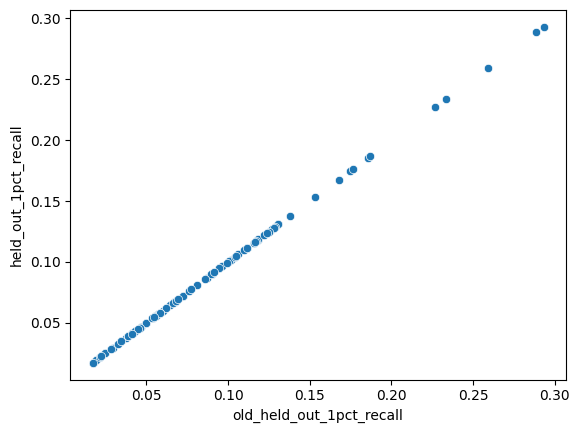

In [3]:
import seaborn as sns
sns.scatterplot(
    data=round_df,
    x='old_held_out_1pct_recall',
    y='held_out_1pct_recall',
)

In [4]:
from folde.util import get_training_loss_df
train_df = get_training_loss_df(results, round_idx=1)
train_df['epoch'] = train_df['log_step'] * 10
train_df.config_name.unique()

array(['FolDE-base', 'FolDE-constantliarS4'], dtype=object)

In [5]:
train_df.groupby(['loss_type', 'config_name', 'sim_idx', 'model_idx']).last()

log_step  \
loss_type            config_name          sim_idx model_idx             
finetune_recall_1pct FolDE-base           0       0                14   
                                                  1                14   
                                                  2                 9   
                                                  3                23   
                                                  4                12   
...                                                               ...   
pretrain_val         FolDE-constantliarS4 4       0                10   
                                                  1                10   
                                                  2                10   
                                                  3                10   
                                                  4                10   

                                                                 loss  \
loss_type            config_name          sim_idx model_idx             
finetune_recall_1pct FolDE-base           0       0          0.064804   
                                                  1          0.061080   
                                                  2          0.058845   
                                                  3          0.059590   
                                                  4          0.058473   
...                                                               ...   
pretrain_val         FolDE-constantliarS4 4       0          0.344708   
                                                  1          0.361406   
                                                  2          0.337005   
                                                  3          0.323257   
                                                  4          0.399435   

                                                                            dms_id  \
loss_type            config_name          sim_idx model_idx                          
finetune_recall_1pct FolDE-base           0       0          SPG1_STRSG_Olson_2014   
                                                  1          SPG1_STRSG_Olson_2014   
                                                  2          SPG1_STRSG_Olson_2014   
                                                  3          SPG1_STRSG_Olson_2014   
                                                  4          SPG1_STRSG_Olson_2014   
...                                                                            ...   
pretrain_val         FolDE-constantliarS4 4       0          SPG1_STRSG_Olson_2014   
                                                  1          SPG1_STRSG_Olson_2014   
                                                  2          SPG1_STRSG_Olson_2014   
                                                  3          SPG1_STRSG_Olson_2014   
                                                  4          SPG1_STRSG_Olson_2014   

                                                             epoch  
loss_type            config_name          sim_idx model_idx         
finetune_recall_1pct FolDE-base           0       0            140  
                                                  1            140  
                                                  2             90  
                                                  3            230  
                                                  4            120  
...                                                            ...  
pretrain_val         FolDE-constantliarS4 4       0            100  
                                                  1            100  
                                                  2            100  
                                                  3            100  
                                                  4            100  

[250 rows x 4 columns]

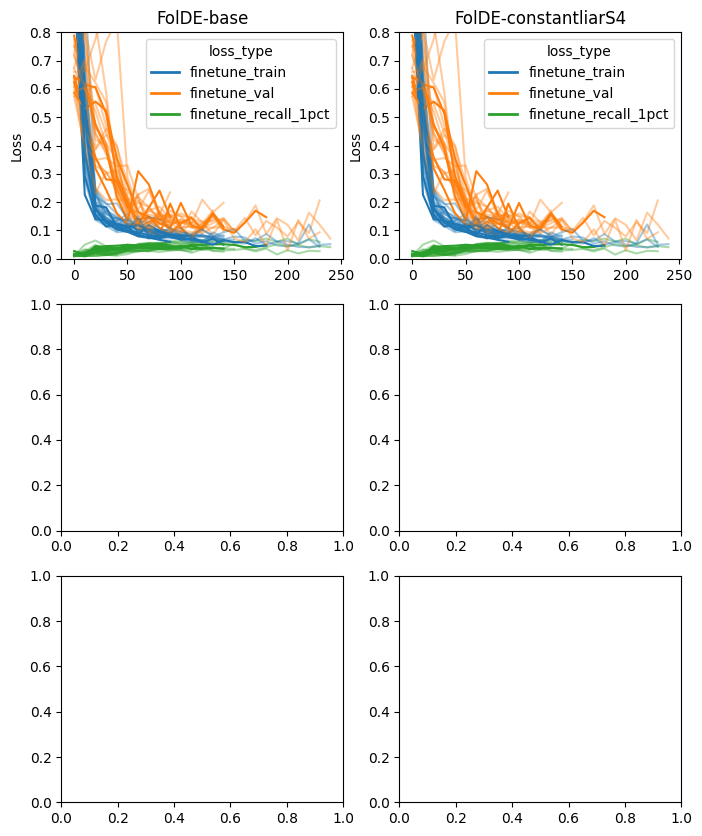

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(8, 10))

for config_name, ax in zip(train_df.config_name.unique(), axs.flatten()):
    plot_df = train_df[
        # (train_df.config_name == 'FolDE_holdout')
        # (train_df.config_name == 'FolDE_reweight_min_holdout')
        (train_df.config_name == config_name)
        # (train_df.config_name == 'FolDE_reweight_max')
        # (train_df.config_name == 'FolDE_base')
        & (train_df.loss_type.str.startswith('finetune'))
    ]

    # Get unique loss_types and assign a color to each
    loss_types = plot_df['loss_type'].unique()
    color_map = {lt: color for lt, color in zip(loss_types, plt.cm.tab10.colors)}
    sim_idx_to_alpha_map = {1: 1.0}


    # Group by sim_idx and model_idx, but color by loss_type
    for (sim_idx, model_idx, loss_type), group in plot_df.groupby(['sim_idx', 'model_idx', 'loss_type']):
        # loss_type = group['loss_type'].iloc[0]
        color = color_map[loss_type]
        alpha = sim_idx_to_alpha_map.get(sim_idx, 0.4)
        ax.plot(group['epoch'], group['loss'], color=color, alpha=alpha)  # alpha for visibility

    # Optionally, add a legend for loss_type
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color=color_map[lt], lw=2, label=lt) for lt in loss_types]
    ax.legend(handles=legend_elements, title='loss_type')

    dms_name = '_'.join(plot_df['dms_id'].unique())
    config_name = '_'.join(plot_df['config_name'].unique())
    ax.set_title(f'{config_name}')

    ax.set_xlabel('')
    ax.set_ylabel('Loss')
    ax.set_ylim(0, 0.8)

In [8]:
from folde.util import convert_compaign_result_collection_to_df

mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df.head()

,dms_id,config_name,sim_num,variant_pool_size,best_activity_this_round,best_percentile_this_round,best_activity_so_far,normalized_best_activity_so_far,best_percentile_so_far,round_num,...,misc,held_out_activity_spearman,held_out_1pct_recall,held_out_1pct_auc,held_out_10pct_recall,held_out_10pct_auc,old_held_out_1pct_recall,old_held_out_1pct_auc,zero_shot_debug_info,few_shot_debug_info
0,SPG1_STRSG_Olson_2014,FolDE-base,0,268481,1.975875,1.975875,1.975875,0.841131,0.996987,1,...,{'held_out_activity_spearman': 0.2743929543335...,0.274393,0.024953,0.542660,0.179411,0.594284,0.024953,0.542660,{'model_type': 'NaturalnessZeroShotModel'},NaN
1,SPG1_STRSG_Olson_2014,FolDE-base,0,268481,1.811341,1.811341,1.975875,0.841131,0.996987,2,...,{'held_out_activity_spearman': 0.2806749684897...,0.280675,0.056983,0.584982,0.210287,0.613124,0.056983,0.584982,NaN,"{'sorts': {'selection_order': ['A250G_E268M', ..."
2,SPG1_STRSG_Olson_2014,FolDE-base,0,268481,1.900863,1.900863,1.975875,0.841131,0.996987,3,...,{'held_out_activity_spearman': 0.2283749933761...,0.228375,0.046927,0.471758,0.197884,0.582567,0.046927,0.471758,NaN,"{'sorts': {'selection_order': ['L233I_A250G', ..."
3,SPG1_STRSG_Olson_2014,FolDE-base,0,268481,2.158498,2.158498,2.158498,0.864472,0.998823,4,...,{'held_out_activity_spearman': 0.3283674387600...,0.328367,0.029423,0.474700,0.211554,0.608885,0.029423,0.474700,NaN,"{'sorts': {'selection_order': ['A250E_E268L', ..."
4,SPG1_STRSG_Olson_2014,FolDE-base,0,268481,2.086502,2.086502,2.158498,0.864472,0.998823,5,...,{'held_out_activity_spearman': 0.2722117948737...,0.272212,0.049907,0.579459,0.239450,0.618961,0.049907,0.579459,NaN,"{'sorts': {'selection_order': ['Q228E_A250E', ..."


In [9]:
training_scores = mutant_df[
    (mutant_df['round_found'] == 3) &
    (mutant_df['sim_num'] == 1) &
    (mutant_df['config_name'] == 'FolDE_base')
].predicted_activity.tolist()
training_scores

[]

In [10]:
round_metrics_df[round_metrics_df['round_num'] == 2].held_out_10pct_recall

1    0.210287
1    0.204849
1    0.193527
1    0.238184
1    0.210473
1    0.210287
1    0.204849
1    0.193527
1    0.238184
1    0.210473
Name: held_out_10pct_recall, dtype: float64

In [11]:
round_metrics_df.columns

Index(['dms_id', 'config_name', 'sim_num', 'variant_pool_size',
       'best_activity_this_round', 'best_percentile_this_round',
       'best_activity_so_far', 'normalized_best_activity_so_far',
       'best_percentile_so_far', 'round_num', 'model_spearman', 'misc',
       'held_out_activity_spearman', 'held_out_1pct_recall',
       'held_out_1pct_auc', 'held_out_10pct_recall', 'held_out_10pct_auc',
       'old_held_out_1pct_recall', 'old_held_out_1pct_auc',
       'zero_shot_debug_info', 'few_shot_debug_info'],
      dtype='object')

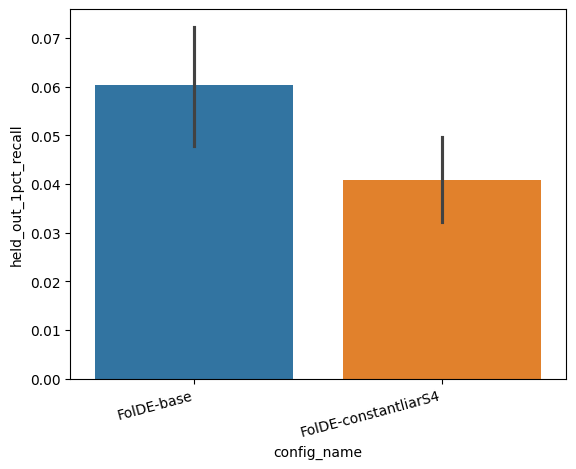

In [12]:
import seaborn as sns
sns.barplot(
    data=round_metrics_df[round_metrics_df['round_num'] == 3],
    x='config_name',
    y='held_out_1pct_recall',
    hue='config_name'
)
plt.xticks(rotation=15, ha='right')
plt.show()


<Axes: xlabel='round_num', ylabel='held_out_1pct_recall'>

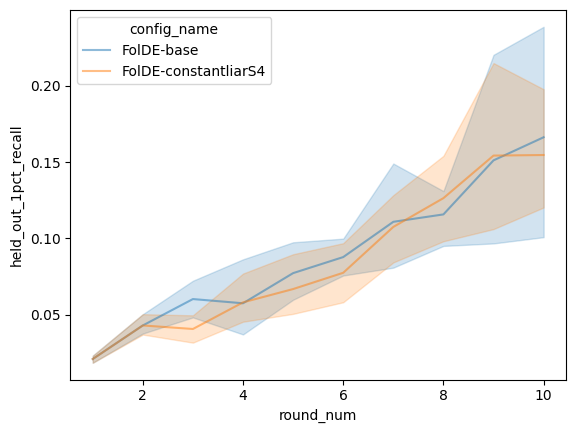

In [13]:
sns.lineplot(
    data=round_metrics_df,
    x='round_num',
    y='held_out_1pct_recall',
    hue='config_name',
    # style='conf',
    alpha=0.5
    # markers=True,
    # dashes=False,
)

In [15]:
s1000 = '''Q63P_F80A
F80P_Q123D
F80A_Y255R
F80A_Q303R
F80S_Q123D
F80N_Q123D
Q63A_F80G
F80A_T215R
F80A_G206R
F80A_F287R
F80A_H92E
F80A_L263K
F80A_S89G
F80A_L263R
F80A_H143A
F80A_H143L
F80A_G206C
W10V_F80A
F80G_Q123D
F80A_P254G
F80A_H143D
F80A_G88R
A20R_F80A
F80A_Y81A'''.split('\n')
s4= '''F80A_G206I
F80A_S204C
F80A_H270R
H8A_F80A
F80A_E205A
F80A_L136V
F80A_G206Y
F80A_T215R
F80A_K137P
F80A_F287R
F80A_G97E
S24D_F80A
Q75C_F80A
F80A_H270M
D25R_F80A
F80A_L140E
F80A_G206C
F80A_Q155C
F80G_Q123D
L56Y_F80A
F80A_T234R
F80A_G206P
F80A_L167C
F80A_Y81A'''.split('\n')

In [16]:
set(s1000) - set(s4)

{'A20R_F80A',
 'F80A_G206R',
 'F80A_G88R',
 'F80A_H143A',
 'F80A_H143D',
 'F80A_H143L',
 'F80A_H92E',
 'F80A_L263K',
 'F80A_L263R',
 'F80A_P254G',
 'F80A_Q303R',
 'F80A_S89G',
 'F80A_Y255R',
 'F80N_Q123D',
 'F80P_Q123D',
 'F80S_Q123D',
 'Q63A_F80G',
 'Q63P_F80A',
 'W10V_F80A'}

In [17]:
set(s4) - set(s1000)

{'D25R_F80A',
 'F80A_E205A',
 'F80A_G206I',
 'F80A_G206P',
 'F80A_G206Y',
 'F80A_G97E',
 'F80A_H270M',
 'F80A_H270R',
 'F80A_K137P',
 'F80A_L136V',
 'F80A_L140E',
 'F80A_L167C',
 'F80A_Q155C',
 'F80A_S204C',
 'F80A_T234R',
 'H8A_F80A',
 'L56Y_F80A',
 'Q75C_F80A',
 'S24D_F80A'}